# Stima della percentuale di massa grassa di un individuo

In [614]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

import statsmodels.api as sm
 
# Selezione delle variabili e stima dei parametri
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import cross_val_score

from sklearn.compose import ColumnTransformer

# Valutazione
from sklearn.metrics import r2_score, mean_squared_error


---

# Massa grassa

La massa grassa di un individuo è la quantità totale di lipidi presenti nel corpo umano, è un parametro fondamentale per verificarne lo stato della salute, possono esistere soggetti con:
- BMI nella norma, dove il BMI è l'indice calcolato tramite il peso normalizzato per l'altezza $\text{BMI}= \frac {\text{Peso}} {\text{Altezza}^2}$.
- Massa grassa alta, quindi l'individuo avrà uno strato di grasso che appanna i muscoli mostrando un fisico meno armonioso.

Questo fenomeno, noto in letteratura come **skinny fat** o **obesità normopeso**, evidenzia come il solo BMI sia un indicatore insufficiente per valutare la composizione corporea reale. 

>Due individui con identico BMI possono infatti presentare composizioni corporee radicalmente diverse: uno con prevalenza di massa muscolare e basso tessuto adiposo, l'altro con scarsa muscolatura e accumulo lipidico significativo.

## Range di riferimento

I valori considerati salutari di percentuale di massa grassa sono indicativamente:

| Categoria | Uomini | Donne |
|-----------|--------|-------|
| Atleti | 6-13% | 14-20% |
| Fitness | 14-17% | 21-24% |
| Accettabile | 18-24% | 25-31% |
| Obesità | ≥ 25% | ≥ 32% |

## Metodi di misurazione tradizionali

Esistono diverse tecniche per misurare la massa grassa, ognuna con un differente compromesso tra accuratezza, costo e accessibilità:

- **DEXA (Dual-Energy X-ray Absorptiometry)**: considerato il gold standard, fornisce una misurazione molto precisa ma richiede strumentazione costosa e l'esposizione a una piccola dose di radiazioni.
 
- **Pesata idrostatica**: calcola la densità corporea tramite uno strumento basato sul principio di Archimede e successivamente stima la massa grassa tramite le formule di Siri o Brozek.
 
- **Plicometria**: tramite uno strumento chiamato plicometro misura la pliche in differenti parti del corpo e calcola la massa grassa tramite:
    1. Calcolo della densità corporea tramite la formula Jackson & Pollock.
    2. Calcolo della massa grassa a partire dalla densità corporea tramite le formule di Siri o Brozek.

- **Bioimpedenziometria (BIA)**: utilizza una corrente elettrica a bassa intensità per stimare la composizione corporea; comoda ma sensibile a stato di idratazione e altre variabili.

- **Formule stimatorie**: equazioni di regressione sviluppate su ampi campioni di popolazione, che permettono di stimare la percentuale di massa grassa a partire da variabili antropometriche di facile misurazione (peso, altezza, età, sesso, circonferenze corporee). Tra le più note ci sono:

### Formula di Deurenberg (1991)

La formula deriva da una regressione lineare multipla basata su:
- La variabile da predirre è la percentuale di massa grassa calcolata tramite la formula di Siri partendo dalla densità corporea calcolata tramite pesata idrostatica.
- Le variabili predittorie sono BMI, età e sesso.

$$
\text{BF} = 1.20 * \text{BMI} + 0.23 * \text{età} - 10.8 * \text{sesso} - 5.4
$$

In [615]:
def deurenberg(bmi, age, gender):
    g = np.asarray(gender)
    if not np.all(np.isin(g, ["M", "F"])):
        raise ValueError("Il genere deve essere F o M")
    sesso = np.where(g == "M", 1, 0)
    return 1.20 * bmi + 0.23 * age - 10.8 * sesso - 5.4

### Formula della U.S. Navy

La formula U.S Navy usa le circonferenze corporee sfruttando il fatto che il grasso si distribuisce in modo prevedibile sul corpo:
$$
\text{BF}_{\text{uomini}} = \frac {495} {1.0324 - 0.19077*\log_{10}(\text{vita} - \text{collo}) + 0.15456 * \log_{10}(\text{altezza})} - 450
$$

$$
\text{BF}_{\text{donne}} = \frac {495} {1.29579 - 0.35004 * \log_{10}(\text{vita} + \text{fianchi} - \text{collo}) + 0.22100 * \log_{10}(\text{altezza})} - 450
$$

Notare che in entrambe le formule circonferenze e altezza sono in cm.

In [616]:
def us_navy(waist, neck, height, gender, hip = None):
    g = np.asarray(gender)
    if not np.all(np.isin(g, ["M", "F"])):
        raise ValueError("Il genere deve essere F o M")
    bf_m = (495 / (1.0324 - 0.19077 * np.log10(waist - neck) + 0.15456 * np.log10(height))) - 450
    bf_f = (495 / (1.29579 - 0.35004 * np.log10(waist + hip - neck) + 0.22100 * np.log10(height))) - 450
    return np.where(g == "M", bf_m, bf_f)

### Formula CUN-BAE (Clínica Universidad de Navarra - Body Adiposity Estimator)

La formula CUN-BAE è un'evoluzione metodologica della formula di Deurenberg:

In [617]:
def cun_bae(bmi, age, gender):
    g = np.asarray(gender)
    if not np.all(np.isin(g, ["M", "F"])):
        raise ValueError("Il genere deve essere F o M")
    sex = np.where(g == "M", 0, 1)
    return (-44.988
            + 0.503 * age
            + 10.689 * sex
            + 3.172 * bmi
            - 0.026 * bmi**2
            + 0.181 * bmi * sex
            - 0.02 * bmi * age
            - 0.005 * bmi**2 * sex
            + 0.00021 * bmi**2 * age)

La seguente formula utilizza la regressione multipla polinomiale e i termini di interazione.

## Limitazioni dei metodi tradizionali

Le formule appena viste trascurano informazioni potenzialmente rilevanti come:
- Distribuzione del grasso e circonferenze corporee (vita-fianchi).
- Dieta.
- Informazioni etniche.

L'obiettivo dello studio sarà quindi battere le formule appena viste andando ad includere ulteriori parametri all'interno delle formule.

---

# Dataset

Il dataset utilizzato è NHANES (National Health and Nutrition Examination Survey), esso contiene migliaia di soggetti, con misurazioni DEXA in alcune annate, dati antropometrici completi, questionari su attività fisica, alimentazione (24h recall).

## Analisi sul contenuto dei dataset

### Misure corporee

In [618]:
df_bmx = pd.read_sas("./db/BMX_J.XPT")
print(f"Keys: {list(df_bmx.keys())}")
print(f"Shape: {df_bmx.shape}")
df_bmx.head()

Keys: ['SEQN', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXRECUM', 'BMIRECUM', 'BMXHEAD', 'BMIHEAD', 'BMXHT', 'BMIHT', 'BMXBMI', 'BMXLEG', 'BMILEG', 'BMXARML', 'BMIARML', 'BMXARMC', 'BMIARMC', 'BMXWAIST', 'BMIWAIST', 'BMXHIP', 'BMIHIP']
Shape: (8704, 21)


,SEQN,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,...,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP
0,93703.0,1.0,13.7,3.0,89.6,NaN,NaN,NaN,88.6,NaN,...,NaN,NaN,18.0,NaN,16.2,NaN,48.2,NaN,NaN,NaN
1,93704.0,1.0,13.9,NaN,95.0,NaN,NaN,NaN,94.2,NaN,...,NaN,NaN,18.6,NaN,15.2,NaN,50.0,NaN,NaN,NaN
2,93705.0,1.0,79.5,NaN,NaN,NaN,NaN,NaN,158.3,NaN,...,37.0,NaN,36.0,NaN,32.0,NaN,101.8,NaN,110.0,NaN
3,93706.0,1.0,66.3,NaN,NaN,NaN,NaN,NaN,175.7,NaN,...,46.6,NaN,38.8,NaN,27.0,NaN,79.3,NaN,94.4,NaN
4,93707.0,1.0,45.4,NaN,NaN,NaN,NaN,NaN,158.4,NaN,...,38.1,NaN,33.8,NaN,21.5,NaN,64.1,NaN,83.0,NaN


Parametri rilevanti:
- **SEQN**: codice identificativo soggetto.
- **BMDSTATS**: codice 1-4 che indica se l'esame antropometrico è stato completato (1), parziale (2), solo altezza (3), non eseguito (4).
- **BMXWT**: peso corporeo in kg.
- **BMXHT**: altezza in cm.
- **BMXBMI**: Body Mass Index calcolato = BMXWT / (BMXHT/100)$^2$.
- **BMXLEG**: lunghezza della coscia (dal piano del bacino al ginocchio) in cm. Nota: nei soggetti obesi la misura può essere distorta dal tessuto adiposo.
- **BMXARML**: lunghezza del braccio superiore in cm.
- **BMXARMC**: circonferenza del braccio (a metà tra spalla e gomito) in cm.
- **BMXWAIST**: circonferenza vita (a livello del bordo superiore della cresta iliaca) in cm.
- **BMXHIP**: circonferenza fianchi (nel punto più largo dei glutei) in cm.

### Informazioni sul soggetti (Età, genere, etnia,...)

In [619]:
df_demo = pd.read_sas("./db/DEMO_J.XPT")
print(f"Keys: {list(df_demo.keys())}")
print(f"Shape: {df_demo.shape}")
df_demo.head()

Keys: ['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMQADFC', 'DMDBORN4', 'DMDCITZN', 'DMDYRSUS', 'DMDEDUC3', 'DMDEDUC2', 'DMDMARTL', 'RIDEXPRG', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY', 'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANGA', 'DMDHHSIZ', 'DMDFMSIZ', 'DMDHHSZA', 'DMDHHSZB', 'DMDHHSZE', 'DMDHRGND', 'DMDHRAGZ', 'DMDHREDZ', 'DMDHRMAZ', 'DMDHSEDZ', 'WTINT2YR', 'WTMEC2YR', 'SDMVPSU', 'SDMVSTRA', 'INDHHIN2', 'INDFMIN2', 'INDFMPIR']
Shape: (9254, 46)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,93703.0,10.0,2.0,2.0,2.0,NaN,5.0,6.0,2.0,27.0,...,3.0,1.0,3.0,9246.491865,8539.731348,2.0,145.0,15.0,15.0,5.00
1,93704.0,10.0,2.0,1.0,2.0,NaN,3.0,3.0,1.0,33.0,...,3.0,1.0,2.0,37338.768343,42566.614750,1.0,143.0,15.0,15.0,5.00
2,93705.0,10.0,2.0,2.0,66.0,NaN,4.0,4.0,2.0,NaN,...,1.0,2.0,NaN,8614.571172,8338.419786,2.0,145.0,3.0,3.0,0.82
3,93706.0,10.0,2.0,1.0,18.0,NaN,5.0,6.0,2.0,222.0,...,3.0,1.0,2.0,8548.632619,8723.439814,2.0,134.0,NaN,NaN,NaN
4,93707.0,10.0,2.0,1.0,13.0,NaN,5.0,7.0,2.0,158.0,...,2.0,1.0,3.0,6769.344567,7064.609730,1.0,138.0,10.0,10.0,1.88


Parametri rilevanti:
- **SEQN**: codice identificativo soggetto.
- **RIAGENDR**: genere del soggetto 1=M, 2=F.
- **RIDAGEYR**: età in anni compiuti.
- **RIDRETH3**: etnia 1 = Messicano-americano, 2 = Altri ispanici, 3 = Bianchi non-ispanici, 4 = Neri non-ispanici, 6 = Asiatici non-ispanici, 7 = Altri/Multirazziali.
- **RIDSTATR**: stato di partecipazione: 1=solo intervista, 2=intervista+esame fisico.
- **RIDEXPRG**: stato di gravidanza: 1=incinta, 2=non incinta, 3=non determinabile.

### Dieta 

In [620]:
df_dr1tot = pd.read_sas("./db/DR1TOT_J.xpt")
print(f"Keys: {list(df_dr1tot.keys())}")
print(f"Shape: {df_dr1tot.shape}")
df_dr1tot.head()

Keys: ['SEQN', 'WTDRD1', 'WTDR2D', 'DR1DRSTZ', 'DR1EXMER', 'DRABF', 'DRDINT', 'DR1DBIH', 'DR1DAY', 'DR1LANG', 'DR1MRESP', 'DR1HELP', 'DBQ095Z', 'DBD100', 'DRQSPREP', 'DR1STY', 'DR1SKY', 'DRQSDIET', 'DRQSDT1', 'DRQSDT2', 'DRQSDT3', 'DRQSDT4', 'DRQSDT5', 'DRQSDT6', 'DRQSDT7', 'DRQSDT8', 'DRQSDT9', 'DRQSDT10', 'DRQSDT11', 'DRQSDT12', 'DRQSDT91', 'DR1TNUMF', 'DR1TKCAL', 'DR1TPROT', 'DR1TCARB', 'DR1TSUGR', 'DR1TFIBE', 'DR1TTFAT', 'DR1TSFAT', 'DR1TMFAT', 'DR1TPFAT', 'DR1TCHOL', 'DR1TATOC', 'DR1TATOA', 'DR1TRET', 'DR1TVARA', 'DR1TACAR', 'DR1TBCAR', 'DR1TCRYP', 'DR1TLYCO', 'DR1TLZ', 'DR1TVB1', 'DR1TVB2', 'DR1TNIAC', 'DR1TVB6', 'DR1TFOLA', 'DR1TFA', 'DR1TFF', 'DR1TFDFE', 'DR1TCHL', 'DR1TVB12', 'DR1TB12A', 'DR1TVC', 'DR1TVD', 'DR1TVK', 'DR1TCALC', 'DR1TPHOS', 'DR1TMAGN', 'DR1TIRON', 'DR1TZINC', 'DR1TCOPP', 'DR1TSODI', 'DR1TPOTA', 'DR1TSELE', 'DR1TCAFF', 'DR1TTHEO', 'DR1TALCO', 'DR1TMOIS', 'DR1TS040', 'DR1TS060', 'DR1TS080', 'DR1TS100', 'DR1TS120', 'DR1TS140', 'DR1TS160', 'DR1TS180', 'DR1TM161', 

,SEQN,WTDRD1,WTDR2D,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,...,DRD370QQ,DRD370R,DRD370RQ,DRD370S,DRD370SQ,DRD370T,DRD370TQ,DRD370U,DRD370UQ,DRD370V
0,93703.0,5.397605e-79,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,8.171401e+04,8.244287e+04,1.0,49.0,2.0,2.0,7.0,2.0,1.0,...,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0
2,93705.0,7.185561e+03,5.640391e+03,1.0,73.0,2.0,2.0,5.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,93706.0,6.463883e+03,5.397605e-79,1.0,86.0,2.0,1.0,NaN,6.0,1.0,...,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0
4,93707.0,1.533378e+04,2.270707e+04,1.0,81.0,2.0,2.0,14.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Parametri rilevanti:
- **SEQN**: codice identificativo soggetto.
- **DR1DRSTZS**: stato del recall: 1=affidabile e completo, 2=incompleto, 4=non affidabile, 5=non riportato.
- **DR1TKCAL**: energia totale kcal.
- **DR1TPROT**: proteine g.
- **DR1TCARB**: carboidrati g.
- **DR1TSUGR**: zuccheri totali g.
- **DR1TFIBE**: fibre g.
- **DR1TTFAT**: grassi totali g.
- **DR1TSFAT**: grassi saturi g.
- **DR1TMFAT**: grassi monoinsaturi g.
- **DR1TPFAT**: grassi polinsaturi g.
- **DR1TCHOL**: colesterolo mg.

### Massa grassa

In [621]:
df_dxx = pd.read_sas("./db/DXX_J.xpt")
print(f"Keys: {list(df_dxx.keys())}")
print(f"Shape: {df_dxx.shape}")
df_dxx.head()

Keys: ['SEQN', 'DXAEXSTS', 'DXAHEBV', 'DXXHEA', 'DXXHEBMC', 'DXXHEBMD', 'DXAHETV', 'DXXHEFAT', 'DXDHELE', 'DXXHELI', 'DXDHETOT', 'DXDHEPF', 'DXALABV', 'DXXLAA', 'DXXLABMC', 'DXXLABMD', 'DXALATV', 'DXXLAFAT', 'DXDLALE', 'DXXLALI', 'DXDLATOT', 'DXDLAPF', 'DXALLBV', 'DXXLLA', 'DXXLLBMC', 'DXXLLBMD', 'DXALLTV', 'DXXLLFAT', 'DXDLLLE', 'DXXLLLI', 'DXDLLTOT', 'DXDLLPF', 'DXARABV', 'DXXRAA', 'DXXRABMC', 'DXXRABMD', 'DXARATV', 'DXXRAFAT', 'DXDRALE', 'DXXRALI', 'DXDRATOT', 'DXDRAPF', 'DXARLBV', 'DXXRLA', 'DXXRLBMC', 'DXXRLBMD', 'DXARLTV', 'DXXRLFAT', 'DXDRLLE', 'DXXRLLI', 'DXDRLTOT', 'DXDRLPF', 'DXXLRA', 'DXXLRBMC', 'DXXLRBMD', 'DXXRRA', 'DXXRRBMC', 'DXXRRBMD', 'DXXTSA', 'DXXTSBMC', 'DXXTSBMD', 'DXXLSA', 'DXXLSBMC', 'DXXLSBMD', 'DXXPEA', 'DXXPEBMC', 'DXXPEBMD', 'DXATRBV', 'DXDTRA', 'DXDTRBMC', 'DXDTRBMD', 'DXATRTV', 'DXXTRFAT', 'DXDTRLE', 'DXXTRLI', 'DXDTRTOT', 'DXDTRPF', 'DXDSTA', 'DXDSTBMC', 'DXDSTBMD', 'DXDSTFAT', 'DXDSTLE', 'DXDSTLI', 'DXDSTTOT', 'DXDSTPF', 'DXDTOA', 'DXDTOBMC', 'DXDTOBMD', 

,SEQN,DXAEXSTS,DXAHEBV,DXXHEA,DXXHEBMC,DXXHEBMD,DXAHETV,DXXHEFAT,DXDHELE,DXXHELI,...,DXDSTTOT,DXDSTPF,DXDTOA,DXDTOBMC,DXDTOBMD,DXDTOFAT,DXDTOLE,DXDTOLI,DXDTOTOT,DXDTOPF
0,93706.0,1.0,5.397605e-79,230.99,370.17,1.603,5.397605e-79,1149.1,3186.6,3556.7,...,61125.9,22.6,2083.82,2097.87,1.007,14968.3,48765.6,50863.5,65831.7,22.7
1,93707.0,1.0,5.397605e-79,223.45,324.64,1.453,5.397605e-79,977.9,2719.5,3044.1,...,41271.5,18.5,1666.11,1467.06,0.881,8602.0,35224.5,36691.6,45293.6,19.0
2,93711.0,1.0,5.397605e-79,241.96,564.83,2.334,5.397605e-79,1114.2,3072.3,3637.1,...,57467.1,22.7,2054.18,2306.83,1.123,14185.8,45725.8,48032.6,62218.4,22.8
3,93712.0,1.0,5.397605e-79,239.04,404.24,1.691,5.397605e-79,1131.7,3140.7,3544.9,...,54686.6,16.1,2073.44,2130.12,1.027,9909.9,47323.2,49453.3,59363.3,16.7
4,93714.0,1.0,5.397605e-79,194.67,494.12,2.538,5.397605e-79,1017.1,2706.1,3200.2,...,83603.6,43.0,1716.47,1878.89,1.095,36938.0,49004.1,50883.0,87820.9,42.1


Parametri rilevanti:
- **SEQN**: codice identificativo soggetto.
- **DXAEXSTS**: stato dell'esame DXA: 1=valido, 2=parziale, 3=non valido.
- **DXDTOPF**: massa grassa totale.

## Filtraggio dei parametri rilevanti

In [622]:
bmx_cols = ["SEQN", "BMDSTATS", "BMXWT", "BMXHT", "BMXBMI", "BMXLEG", "BMXARML", "BMXARMC", "BMXWAIST", "BMXHIP"]

demo_cols = ["SEQN", "RIAGENDR", "RIDAGEYR", "RIDRETH3", "RIDSTATR", "RIDEXPRG"]

dxx_cols = ["SEQN", "DXAEXSTS", "DXDTOPF"]

dr1tot_cols = ["SEQN", "DR1DRSTZ", "DR1TKCAL", "DR1TPROT", "DR1TCARB", "DR1TTFAT"]


df_filtered = (
    df_dxx[dxx_cols]
    .merge(df_demo[demo_cols], on="SEQN", how="inner") # se un soggetto è in DXX ma non in demo viene scartato
    .merge(df_bmx[bmx_cols], on="SEQN", how="inner")
    .merge(df_dr1tot[dr1tot_cols], on="SEQN", how="left") # se un soggetto è presente a sinistra ma non a destra mette NaN
)

print(f"Shape: {df_filtered.shape}")
df_filtered.head()

Shape: (5114, 22)


,SEQN,DXAEXSTS,DXDTOPF,RIAGENDR,RIDAGEYR,RIDRETH3,RIDSTATR,RIDEXPRG,BMDSTATS,BMXWT,...,BMXLEG,BMXARML,BMXARMC,BMXWAIST,BMXHIP,DR1DRSTZ,DR1TKCAL,DR1TPROT,DR1TCARB,DR1TTFAT
0,93706.0,1.0,22.7,1.0,18.0,6.0,2.0,NaN,1.0,66.3,...,46.6,38.8,27.0,79.3,94.4,1.0,1987.0,94.19,89.82,137.39
1,93707.0,1.0,19.0,1.0,13.0,7.0,2.0,NaN,1.0,45.4,...,38.1,33.8,21.5,64.1,83.0,1.0,1775.0,59.48,188.15,89.18
2,93711.0,1.0,22.8,1.0,56.0,6.0,2.0,NaN,1.0,62.1,...,40.1,37.2,30.8,86.6,90.7,1.0,2840.0,101.33,339.60,124.24
3,93712.0,1.0,16.7,1.0,18.0,1.0,2.0,NaN,1.0,58.9,...,44.5,37.2,28.7,72.0,88.2,1.0,2045.0,99.66,268.24,63.90
4,93714.0,1.0,42.1,2.0,54.0,4.0,2.0,NaN,1.0,87.1,...,26.0,32.0,34.7,118.4,133.1,1.0,2493.0,104.10,208.12,143.18


In [623]:
df_filtered = df_filtered[df_filtered["DXAEXSTS"] == 1] # filtraggio per DEXA valida
df_filtered = df_filtered[df_filtered["BMDSTATS"] == 1] # filtraggio per antropometria completa
df_filtered = df_filtered[df_filtered["RIDSTATR"] == 2] # filtraggio per intervista + esame fisico effettuato
df_filtered = df_filtered[df_filtered["RIDEXPRG"] != 1] # filtraggio per escludere gravide (NaN = uomini/non in età fertile, da tenere), la percentuale di massa grassa su una donna incinta è incorretta
df_filtered = df_filtered[df_filtered["DR1DRSTZ"] == 1] # filtraggio per dati dietetici 

df_filtered = df_filtered.drop(columns=["DXAEXSTS", "BMDSTATS", "RIDSTATR", "RIDEXPRG", "DR1DRSTZ"])
print(f"Shape: {df_filtered.shape}")

Shape: (3932, 17)


### Variabili numeriche risultanti

In [624]:
num_vars = df_filtered.select_dtypes(include="number")
print(num_vars.keys())

Index(['SEQN', 'DXDTOPF', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH3', 'BMXWT', 'BMXHT',
       'BMXBMI', 'BMXLEG', 'BMXARML', 'BMXARMC', 'BMXWAIST', 'BMXHIP',
       'DR1TKCAL', 'DR1TPROT', 'DR1TCARB', 'DR1TTFAT'],
      dtype='str')


### Variabili categoriche risultanti

In [625]:
cat_vars = df_filtered.select_dtypes(include="str")
print(cat_vars.keys())

Index([], dtype='str')


Non vengono visualizzate come variabili categoriche sotto forma di stringa, tuttavia conoscendo il contenuto delle varie colonne avremmo che:
- **RIAGENDR**: indica il genere del soggetto 1=M, 2=F.
- **RIDRETH3**: indica l'etnia del soggetto etnia 1 = Messicano-americano, 2 = Altri ispanici, 3 = Bianchi non-ispanici, 4 = Neri non-ispanici, 6 = Asiatici non-ispanici, 7 = Altri/Multirazziali.

Queste dovranno essere convertire in one-hot encoding.

## Verifica dei valori nulli e aggiustamento

In [626]:
print(f"NaN per colonna:\n{df_filtered.isna().sum()}")

NaN per colonna:
SEQN          0
DXDTOPF     612
RIAGENDR      0
RIDAGEYR      0
RIDRETH3      0
BMXWT         0
BMXHT         0
BMXBMI        0
BMXLEG        0
BMXARML       0
BMXARMC       0
BMXWAIST      0
BMXHIP      506
DR1TKCAL      0
DR1TPROT      0
DR1TCARB      0
DR1TTFAT      0
dtype: int64


Sono presenti differenti righe NaN per la colonna DXDTOPF, ovvero la colonna che dovremmo predirre, perciò la soluzione migliore in questo caso sarà rimuovere queste righe NaN.

In [627]:
df_cleaned = df_filtered.dropna(subset=["DXDTOPF", "BMXHIP"]).reset_index(drop=True)
print(f"Shape: {df_cleaned.shape}")
print(f"NaN per colonna:\n{df_cleaned.isna().sum()}")

Shape: (2853, 17)
NaN per colonna:
SEQN        0
DXDTOPF     0
RIAGENDR    0
RIDAGEYR    0
RIDRETH3    0
BMXWT       0
BMXHT       0
BMXBMI      0
BMXLEG      0
BMXARML     0
BMXARMC     0
BMXWAIST    0
BMXHIP      0
DR1TKCAL    0
DR1TPROT    0
DR1TCARB    0
DR1TTFAT    0
dtype: int64


## Analisi degli outlier e dei valori anomali e aggiustamento/rimozione

Funzione di utils per plottare gli istogrammi:

In [628]:
def plot_hist(df):
    df_hist = df.drop(columns=["SEQN", "RIAGENDR", "RIDRETH3"])

    axes = df_hist.hist(bins=30, figsize=(15, 10))
    for ax in axes.flatten():
        col = ax.get_title()  
        
        if col in df_hist.columns:
            mean = df_hist[col].mean()
            median = df_hist[col].median()
            
            ax.axvline(mean, color='red', linestyle='--', linewidth=1.5, label='Media')
            ax.axvline(median, color='black', linestyle='--', linewidth=1.5, label='Mediana')
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

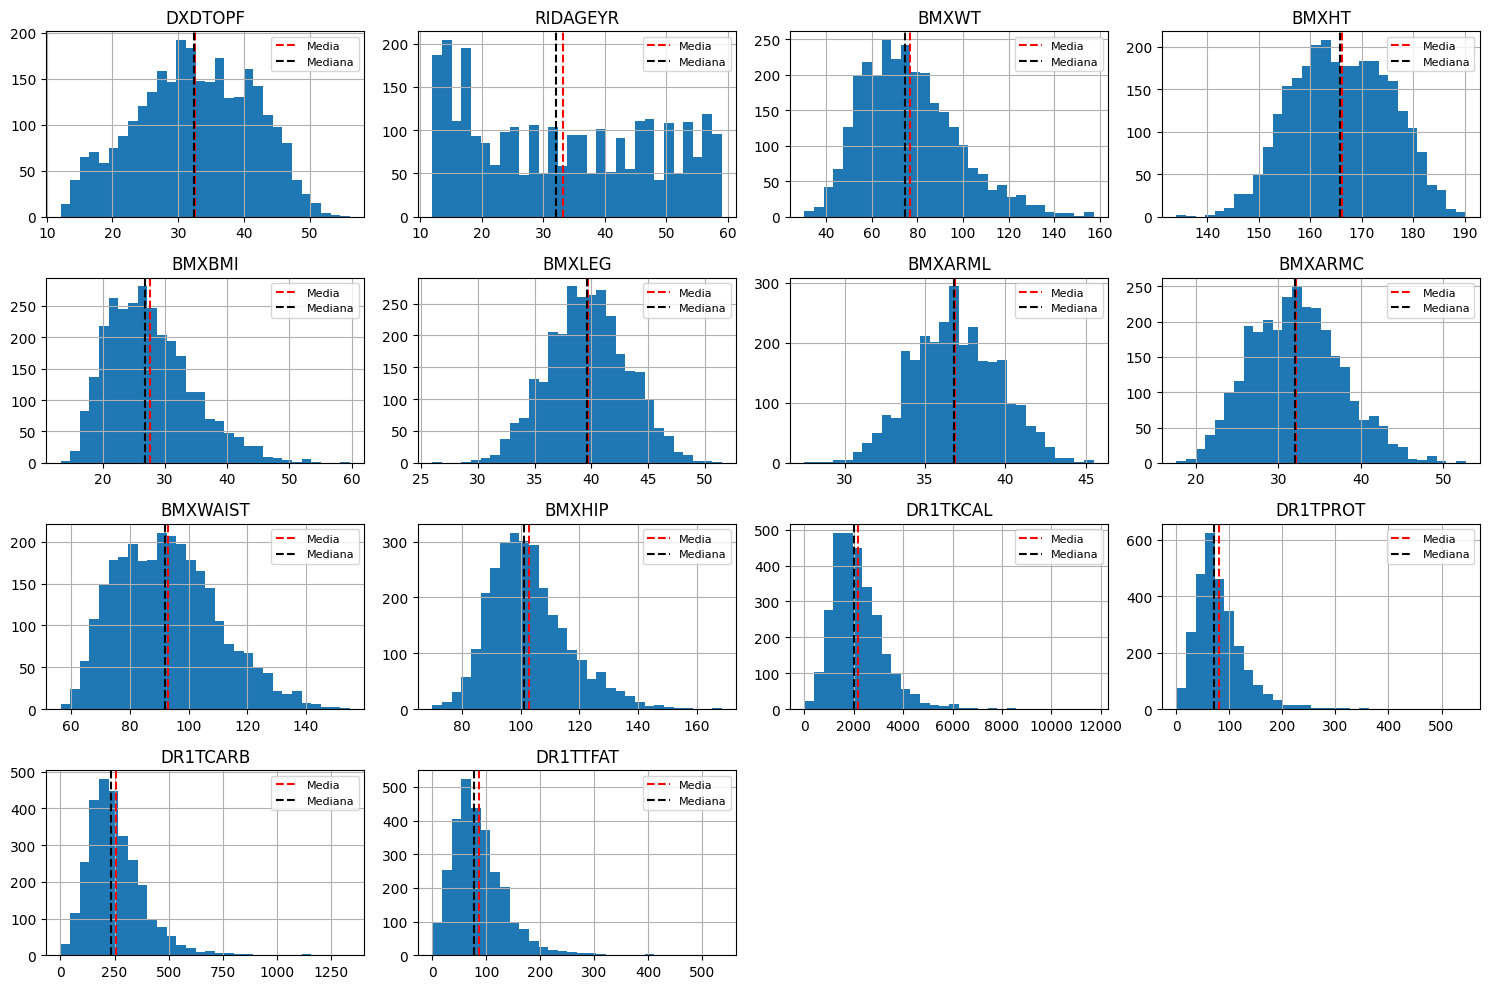

In [629]:
plot_hist(df_cleaned)

In [630]:
df_cleaned.describe(percentiles=[.001, .01, .25, .5, .75, .99, .999])

,SEQN,DXDTOPF,RIAGENDR,RIDAGEYR,RIDRETH3,BMXWT,BMXHT,BMXBMI,BMXLEG,BMXARML,BMXARMC,BMXWAIST,BMXHIP,DR1TKCAL,DR1TPROT,DR1TCARB,DR1TTFAT
count,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2.853000e+03,2853.000000,2.853000e+03
mean,98316.109709,32.488363,1.509288,33.164388,3.553102,76.618472,166.131195,27.645145,39.673887,36.877848,32.134315,92.911146,102.723589,2163.674378,8.097156e+01,257.850340,8.631077e+01
std,2674.221121,8.823019,0.500001,14.766152,1.806487,20.937642,9.364602,6.822681,3.505503,2.702221,5.458216,17.095861,13.248343,1072.636995,4.633259e+01,135.318339,5.169234e+01
min,93706.000000,12.100000,1.000000,12.000000,1.000000,30.300000,134.000000,13.200000,26.000000,27.500000,17.600000,56.400000,70.000000,3.000000,5.397605e-79,1.000000,5.397605e-79
0.1%,93711.852000,12.755600,1.000000,12.000000,1.000000,31.655600,139.426400,14.770400,29.185200,29.255600,18.896400,58.411200,71.400000,87.556000,1.778000e-01,13.021120,4.970400e-01
1%,93808.600000,14.300000,1.000000,12.000000,1.000000,39.652000,145.652000,16.500000,32.000000,31.000000,21.200000,62.900000,77.952000,448.920000,9.013200e+00,43.354400,9.080000e+00
25%,96034.000000,26.100000,1.000000,19.000000,2.000000,60.800000,159.100000,22.400000,37.300000,35.000000,28.100000,79.500000,93.500000,1443.000000,5.101000e+01,168.370000,5.176000e+01
50%,98308.000000,32.400000,2.000000,32.000000,3.000000,74.300000,165.900000,26.700000,39.600000,36.800000,32.000000,92.000000,101.100000,1993.000000,7.193000e+01,235.120000,7.743000e+01
75%,100627.000000,39.600000,2.000000,46.000000,4.000000,89.100000,173.400000,31.700000,42.000000,38.800000,35.700000,103.700000,110.000000,2692.000000,1.020300e+02,322.670000,1.099400e+02
99%,102857.480000,49.748000,2.000000,59.000000,7.000000,134.640000,185.400000,46.296000,47.748000,43.000000,45.300000,136.548000,139.740000,5892.160000,2.380848e+02,713.445200,2.663200e+02


In [631]:
df_cleaned.nlargest(10, "DXDTOPF")

,SEQN,DXDTOPF,RIAGENDR,RIDAGEYR,RIDRETH3,BMXWT,BMXHT,BMXBMI,BMXLEG,BMXARML,BMXARMC,BMXWAIST,BMXHIP,DR1TKCAL,DR1TPROT,DR1TCARB,DR1TTFAT
2083,100434.0,56.1,2.0,32.0,1.0,104.5,152.5,44.9,34.8,33.7,41.3,122.2,137.5,748.0,95.28,20.30,31.54
2679,102401.0,54.2,2.0,44.0,2.0,46.4,153.2,19.8,36.0,33.6,23.6,80.0,96.4,810.0,40.22,111.49,23.71
1276,97756.0,53.5,2.0,23.0,1.0,154.6,160.9,59.7,35.0,38.0,52.7,143.0,148.8,2539.0,72.24,339.99,105.33
762,96196.0,52.5,2.0,34.0,3.0,157.4,163.2,59.1,38.0,33.8,43.1,154.9,168.5,1110.0,83.54,108.72,37.46
2597,102190.0,52.5,2.0,16.0,3.0,144.8,176.2,46.6,45.8,41.0,44.7,114.1,149.6,839.0,30.12,105.42,35.83
900,96600.0,52.3,2.0,25.0,4.0,103.1,155.8,42.5,42.6,35.8,39.9,111.1,128.4,1345.0,38.41,101.60,56.70
436,95153.0,52.1,2.0,23.0,3.0,108.8,158.4,43.4,38.5,35.1,42.2,121.7,134.9,1826.0,68.51,241.51,65.65
2547,102012.0,51.6,2.0,48.0,4.0,125.6,151.6,54.7,40.8,36.0,45.3,128.1,148.1,1002.0,9.69,144.09,45.31
131,94131.0,51.5,2.0,39.0,3.0,129.0,169.1,45.1,38.0,39.1,43.1,135.5,148.3,1700.0,54.09,244.96,58.86
2807,102793.0,51.5,2.0,30.0,3.0,105.7,155.1,43.9,38.7,36.5,41.9,127.3,139.5,1827.0,77.40,253.83,56.93


In [632]:
df_cleaned.nlargest(10, "DR1TKCAL")

,SEQN,DXDTOPF,RIAGENDR,RIDAGEYR,RIDRETH3,BMXWT,BMXHT,BMXBMI,BMXLEG,BMXARML,BMXARMC,BMXWAIST,BMXHIP,DR1TKCAL,DR1TPROT,DR1TCARB,DR1TTFAT
732,96092.0,15.8,1.0,22.0,2.0,56.1,171.9,19.0,42.1,34.3,28.4,71.6,85.2,11710.0,440.73,1120.01,536.10
2712,102492.0,27.5,1.0,31.0,4.0,100.9,182.7,30.2,48.8,42.4,39.2,100.4,108.5,10477.0,334.82,1336.27,410.11
1191,97490.0,21.5,1.0,17.0,3.0,66.9,167.4,23.9,40.4,35.0,30.2,84.5,93.8,9466.0,181.13,1264.87,414.27
1381,98124.0,31.5,1.0,31.0,3.0,71.8,170.3,24.8,41.4,36.5,29.9,92.4,96.5,8538.0,128.52,1154.42,395.84
723,96066.0,19.7,1.0,52.0,7.0,61.4,169.0,21.5,39.4,35.6,26.7,78.8,86.8,8241.0,238.22,638.98,277.95
855,96463.0,17.6,1.0,26.0,1.0,62.3,176.9,19.9,44.2,38.1,29.7,77.1,83.0,7658.0,173.22,1138.89,286.67
202,94356.0,25.8,1.0,58.0,4.0,91.3,182.1,27.5,44.0,42.2,33.5,105.1,103.4,7627.0,354.18,689.30,373.09
1076,97142.0,40.9,2.0,44.0,1.0,79.6,156.4,32.5,36.2,35.4,34.0,103.8,109.6,7463.0,316.91,691.05,379.62
1030,97032.0,22.9,1.0,50.0,3.0,88.0,182.3,26.5,43.0,38.4,33.4,96.4,102.3,7284.0,545.20,401.52,250.49
234,94465.0,23.0,1.0,31.0,7.0,106.2,185.4,30.9,42.0,40.7,38.0,104.7,109.4,7021.0,213.77,861.54,274.39


Per identificare i valori anomali usiamo due **cross-check** fra misurazioni indipendenti che dovrebbero concordare:

1. **Kcal dichiarate vs ricalcolate**: applichiamo la formula di Atwater alle quantità di proteine, carboidrati e grassi (4 + 4 + 9 kcal/g). Differenze maggiori del 15% indicano incoerenze nel recall dietetico. La tolleranza è ampia perché non includiamo l'alcool (7 kcal/g) e le fibre hanno densità calorica variabile.

2. **BMI dichiarato vs ricalcolato**: applichiamo la classica formula per il calcolo del BMI come il peso normalizzato per l'altezza alla seconda. Differenze superiori a 2 punti indicano errori di trascrizione.


In [633]:
# Check 1: kcal dichiarate vs ricalcolate (Atwater: 4P + 4C + 9F)
kcal_calc = 4 * df_cleaned["DR1TPROT"] + 4 * df_cleaned["DR1TCARB"] + 9 * df_cleaned["DR1TTFAT"]
kcal_diff_pct = ((kcal_calc - df_cleaned["DR1TKCAL"]) / df_cleaned["DR1TKCAL"]).abs()
mask_kcal = kcal_diff_pct <= 0.15 

# Check 2: BMI vs Weight / Height^2
bmi_cal = df_cleaned["BMXWT"] / (df_cleaned["BMXHT"] / 100)**2
bmi_diff = (df_cleaned["BMXBMI"] - bmi_cal).abs()
mask_bmi = bmi_diff <= 2

print(f"Valori anomali rilevati:")
print(f"  Kcal dichiarate vs Atwater (>15%): {(~mask_kcal).sum():4d}")
print(f"  BMI dichiarato vs BMI calcolato (>2 punti): {(~mask_bmi).sum():4d}")

mask = mask_kcal & mask_bmi
print(f"\nTotale rimossi: {(~mask).sum()} su {len(df_cleaned)}")

df_cleaned = df_cleaned[mask].reset_index(drop=True)
print(f"Shape finale: {df_cleaned.shape}")

Valori anomali rilevati:
  Kcal dichiarate vs Atwater (>15%):  147
  BMI dichiarato vs BMI calcolato (>2 punti):    0

Totale rimossi: 147 su 2853
Shape finale: (2706, 17)


Per rimuovere i valori di bordo andiamo invece a eseguire un filtro tramite percentile per ciascuna colonna:

In [634]:
percentile_cols = [c for c in df_cleaned.columns if c not in ["SEQN", "RIAGENDR", "RIDRETH3"]]

lo = df_cleaned[percentile_cols].quantile(0.001) 
hi = df_cleaned[percentile_cols].quantile(0.999)
mask_pct = ((df_cleaned[percentile_cols] >= lo) & (df_cleaned[percentile_cols] <= hi)).all(axis=1)

print(f"Soggetti rimossi dal filtro percentile [0.001 - 0.999]: {(~mask_pct).sum()}")
df_cleaned = df_cleaned[mask_pct].reset_index(drop=True)
print(f"Shape finale: {df_cleaned.shape}")

Soggetti rimossi dal filtro percentile [0.001 - 0.999]: 51
Shape finale: (2655, 17)


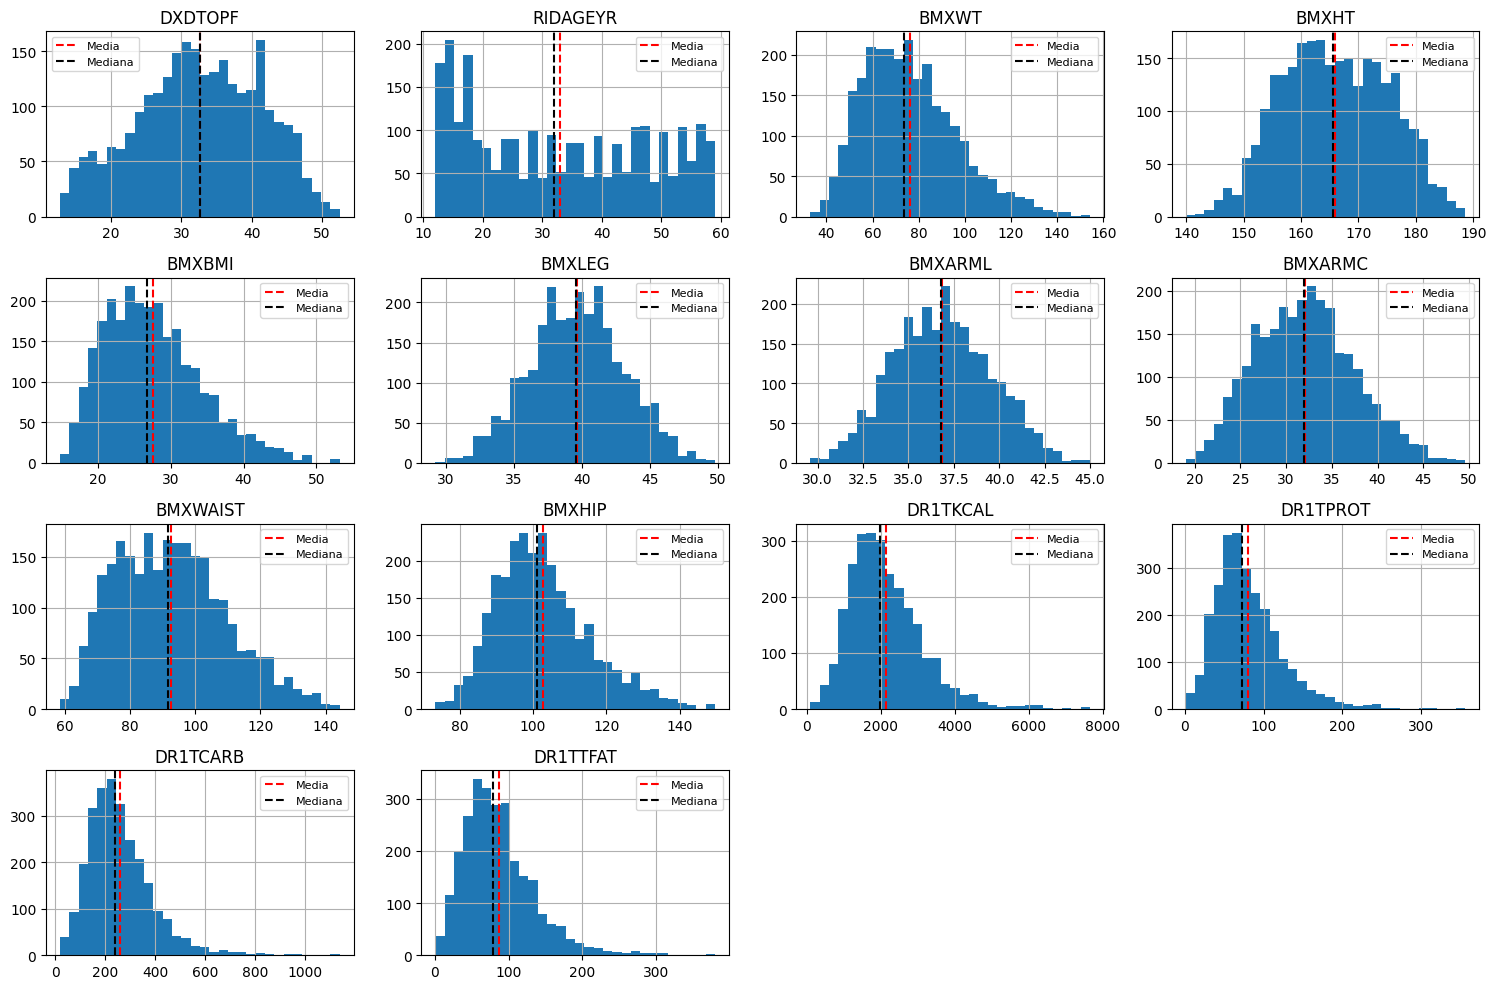

In [635]:
plot_hist(df_cleaned)

#

---

# Selezione delle variabili

## Variabili categoriali

Possiamo studiare la relazione presente tra la massa grassa e le variabili categoriali presenti all'interno del dataset preprocessato. Le variabili categoriali presenti sono:
- Genere.
- Etnia.

Quindi possiamo eseguire uno studio prima andando a verificare:
- La relazione tra Genere - Massa grassa, l'obiettivo della verifica sarà mostrare se il genere influenza in qualche modo la massa grassa.
- La relazione tra Etnia - Massa grassa, l'obiettivo della verifica sarà mostrare se l'etnia influenza in qualche modo la massa massa grassa.
- La relazione tra Etnia - Genere, l'obiettivo della verificare se la proporzione di maschi e femmine è la stessa in tutte le etnie, o se invece cambia da un'etnia all'altra, questo è un check che torna utile per verificare la distribuzione del dataset prima di verificare l'interazione tra genere e etnia sulla massa grassa.  
- L'interazione tra Genere x Etnia - Massa grassa, l'obiettivo della verifica sarà mostrare come genere ed etnia, insieme, influenzano la massa grassa.

### Genere - Massa grassa (ANOVA a una via)

Verifichiamo se il genere è associato all'etnia andando ad utilizzare ANOVA a una via in modo da confrontare le medie dei vari gruppi:

In [636]:
gen_map = {
    1: "Male",
    2: "Female",
}

gen_series = df_cleaned["RIAGENDR"].map(gen_map) # mappa gli indici con le relative etnie 
groups_gen_bf = [df_cleaned.loc[gen_series == gen, "DXDTOPF"] for gen in gen_map.values()] # raggruppa i valori per ciascuna etnia

desc_gen = pd.DataFrame(
    {
        "n": [g.size for g in groups_gen_bf],
        "media_BF": [g.mean() for g in groups_gen_bf],
        "std_BF": [g.std() for g in groups_gen_bf],
    },
    index=list(gen_map.values()),
)
print("Statistiche descrittive del BF per etnia:")
print(desc_gen)

Statistiche descrittive del BF per etnia:
           n   media_BF    std_BF
Male    1275  26.934196  7.025744
Female  1380  37.859783  6.623539


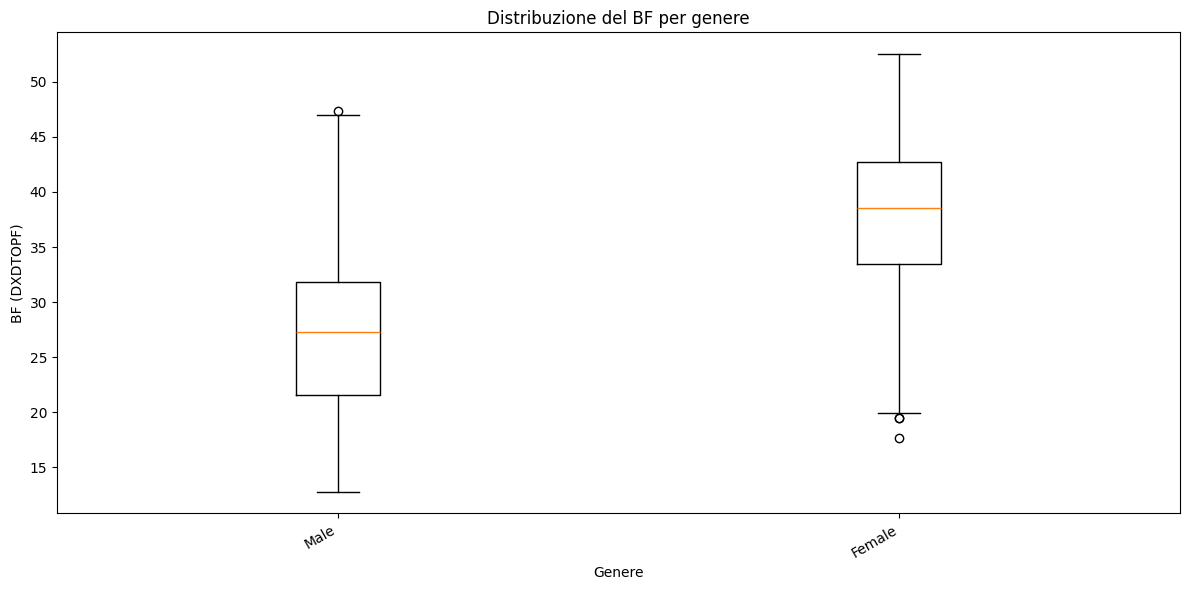

In [637]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot([g.to_numpy() for g in groups_gen_bf], tick_labels=list(gen_map.values()))
ax.set_title("Distribuzione del BF per genere")
ax.set_xlabel("Genere")
ax.set_ylabel("BF (DXDTOPF)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Il boxplot mostra la distribuzione delle masse grasse per entrambi i sessi, già da essi possiamo notare come al variare del genere varia di parecchio la mediana, il 25° percentile e il 75° percentile (e gli outlier).

Tuttavia utilizzando ANOVA possiamo avere un risultato più accurato che ci dice nello specifico se effettivamente il genere influenza o meno la massa grassa, ciò tramite la risoluzione delle seguenti ipotesi:
- $H_0$: la BF media è **uguale** per entrambi i sessi ($\mu_M = \mu_F$), quindi il genere non influenza la massa grassa.
- $H_1$: i generi hanno una BF media diverso tra di loro, quindi il genere influenza la massa grassa.

In [638]:
F, p_value = stats.f_oneway(*groups_gen_bf)

print(f"F = {F:.4f}, p-value = {p_value:.6e}")
if p_value < 0.05:
    print("-> RIFIUTO H0: la BF media differisce tra i generi")
else:
    print("-> NON RIFIUTO H0: nessuna evidenza di differenza la BF media e i generi")

F = 1700.9477, p-value = 1.006375e-287
-> RIFIUTO H0: la BF media differisce tra i generi


### Etnia - Massa grassa (ANOVA a una via)

Verifichiamo se la massa grassa è associata all'etnia andando ad utilizzare ANOVA a una via in modo da confrontare le medie dei vari gruppi:

In [639]:
eth_map = {
    1.0: "Mexican-American",
    2.0: "Other Hispanic",
    3.0: "Non-Hispanic White",
    4.0: "Non-Hispanic Black",
    6.0: "Non-Hispanic Asian",
    7.0: "Other/Multi-Racial",
}

eth_series = df_cleaned["RIDRETH3"].map(eth_map) # mappa gli indici con le relative etnie 
groups_eth_bf = [df_cleaned.loc[eth_series == eth, "DXDTOPF"] for eth in eth_map.values()] # raggruppa i valori per ciascuna etnia

desc_eth = pd.DataFrame(
    {
        "n": [g.size for g in groups_eth_bf],
        "media_BF": [g.mean() for g in groups_eth_bf],
        "std_BF": [g.std() for g in groups_eth_bf],
    },
    index=list(eth_map.values()),
)
print("Statistiche descrittive del BF per etnia:")
print(desc_eth)

Statistiche descrittive del BF per etnia:
                      n   media_BF     std_BF
Mexican-American    444  34.237838   7.998274
Other Hispanic      251  33.351793   8.581479
Non-Hispanic White  820  32.796220   8.816540
Non-Hispanic Black  494  31.141498  10.297933
Non-Hispanic Asian  453  32.112141   7.037935
Other/Multi-Racial  193  32.078238   8.789746


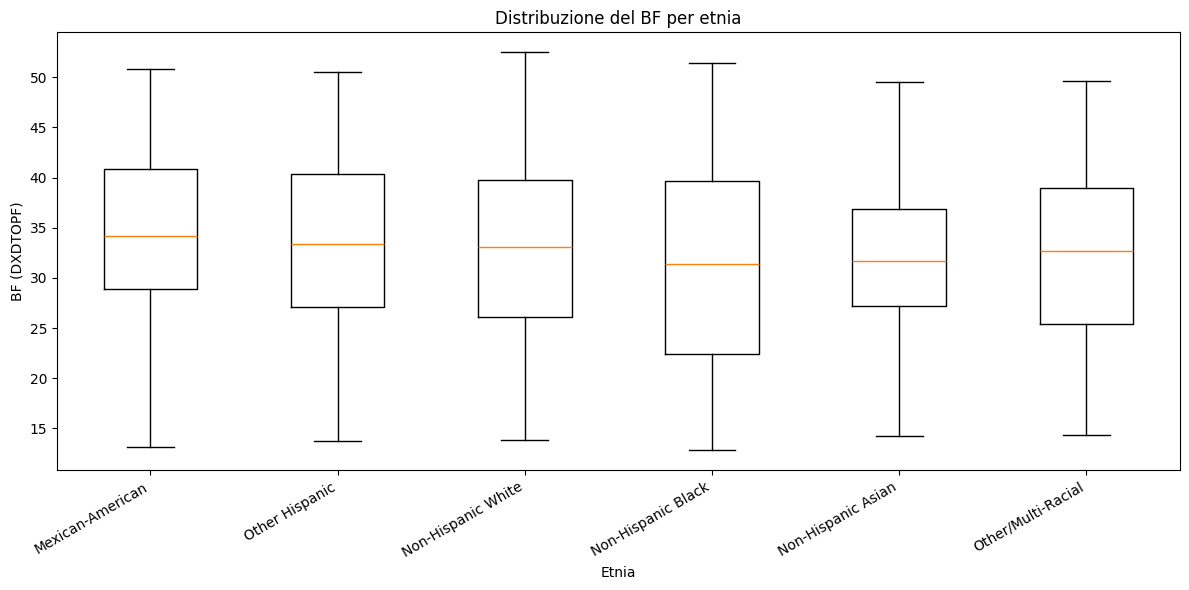

In [640]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot([g.to_numpy() for g in groups_eth_bf], tick_labels=list(eth_map.values()))
ax.set_title("Distribuzione del BF per etnia")
ax.set_xlabel("Etnia")
ax.set_ylabel("BF (DXDTOPF)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Il boxplot mostra la distribuzione delle masse grasse per le varie etnie, già da essi possiamo notare come al variare dell'etnia varia leggermente anche la mediana, il 25° percentile e il 75° percentile (e gli outlier).
 
Tuttavia utilizzando ANOVA possiamo avere un risultato più accurato che ci dice nello specifico se effettivamente la l'etnia influenza o meno la massa grassa, ciò tramite la risoluzione delle seguenti ipotesi:
- $H_0$: la BF media è **uguale** in tutti i gruppi etnici ($\mu_1 = \mu_2 = \dots = \mu_k$), quindi l'etnia non influenza la massa grassa.
- $H_1$: almeno un gruppo etnico ha una BF media diverso dagli altri, quindi l'etnia influenza la massa grassa.

In [641]:
F, p_value = stats.f_oneway(*groups_eth_bf)

print(f"F = {F:.4f}, p-value = {p_value:.6e}")
if p_value < 0.05:
    print("-> RIFIUTO H0: la BF media differisce tra le etnie")
else:
    print("-> NON RIFIUTO H0: nessuna evidenza di differenza della BF medio tra le etnie")

F = 6.8246, p-value = 2.464871e-06
-> RIFIUTO H0: la BF media differisce tra le etnie


Quindi possiamo affermare che l'etnia va a incidere effettivamente sulla massa grassa.

### Genere - Etnia

Verifichiamo se il genere se la proporzione di maschi e di femmine risulta la stessa per tutte le etnie andando ad utilizzare il Test del Chi-Quadro per le Tabelle di Contingenza:

In [642]:
cont_table = pd.crosstab(eth_series, gen_series)
print("Tabella di contingenza osservata (Etnia x Genere):")
print(cont_table)
print()

chi2, p_value, dof, expected = stats.chi2_contingency(cont_table)
expected = np.array(expected)

# frequenze attese sotto H0 (proporzione M/F identica in ogni etnia)
exp_df = pd.DataFrame(expected, index=cont_table.index, columns=cont_table.columns)
print("Frequenze attese sotto H0 (indipendenza):")
print(exp_df.round(1))
print()

n_below_5 = (expected < 5).sum() # verifica di validita del test: tutte le attese dovrebbero essere >= 5
print(f"Celle con frequenza attesa < 5: {n_below_5} su {expected.size}")
print(f"Chi-quadro = {chi2:.2f}, dof = {dof}, p-value = {p_value:.6e}")
print()

if p_value < 0.05: # type: ignore problema legato a pylance
    print("-> RIFIUTO H0: la proporzione maschi/femmine NON è la stessa in tutte le etnie")
else:
    print("-> NON RIFIUTO H0: la proporzione maschine/femmine è omogenea tra le etnie")

Tabella di contingenza osservata (Etnia x Genere):
RIAGENDR            Female  Male
RIDRETH3                        
Mexican-American       238   206
Non-Hispanic Asian     224   229
Non-Hispanic Black     245   249
Non-Hispanic White     450   370
Other Hispanic         135   116
Other/Multi-Racial      88   105

Frequenze attese sotto H0 (indipendenza):
RIAGENDR            Female   Male
RIDRETH3                         
Mexican-American     230.8  213.2
Non-Hispanic Asian   235.5  217.5
Non-Hispanic Black   256.8  237.2
Non-Hispanic White   426.2  393.8
Other Hispanic       130.5  120.5
Other/Multi-Racial   100.3   92.7

Celle con frequenza attesa < 5: 0 su 12
Chi-quadro = 9.00, dof = 5, p-value = 1.092260e-01

-> NON RIFIUTO H0: la proporzione maschine/femmine è omogenea tra le etnie


### Genere x Etnia - Massa grassa

Verifichiamo l'interazione tra il genere e l'etnia nel contesto di influenza sulla massa grassa, cioè se l'effetto di uno cambia a seconda dei livelli dell'altro, andando ad utilizzare ANOVA a due vie:

In [643]:
df_anova = pd.DataFrame(
    {
        "BF": df_cleaned["DXDTOPF"],
        "Genere": df_cleaned["RIAGENDR"].map(gen_map),
        "Etnia": df_cleaned["RIDRETH3"].map(eth_map),
    }
)

desc_cells = df_anova.groupby(["Etnia", "Genere"])["BF"].agg(["size", "mean", "std"])
print("Statistiche descrittive del BF per cella (Genere x Etnia):")
print(desc_cells)

Statistiche descrittive del BF per cella (Genere x Etnia):
                           size       mean       std
Etnia              Genere                           
Mexican-American   Female   238  38.941597  5.888700
                   Male     206  28.803398  6.541316
Non-Hispanic Asian Female   224  36.403571  5.714264
                   Male     229  27.914410  5.519766
Non-Hispanic Black Female   245  38.305306  7.399375
                   Male     249  24.092771  7.507337
Non-Hispanic White Female   450  37.466444  7.025199
                   Male     370  27.116216  7.315993
Other Hispanic     Female   135  38.938519  5.962207
                   Male     116  26.850000  6.276090
Other/Multi-Racial Female    88  37.756818  6.509406
                   Male     105  27.319048  7.552090


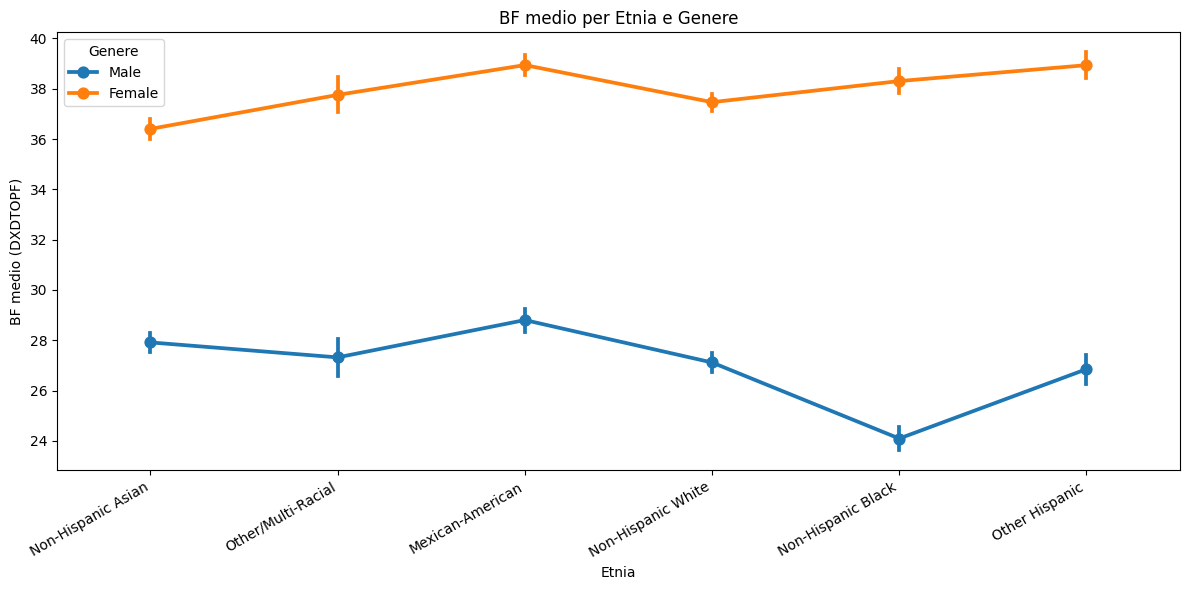

In [644]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.pointplot(data=df_anova, x="Etnia", y="BF", hue="Genere", errorbar="se", ax=ax)
ax.set_title("BF medio per Etnia e Genere")
ax.set_xlabel("Etnia")
ax.set_ylabel("BF medio (DXDTOPF)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Il point plot mostra le medie di BF dei differenti gruppi, vale che se le linee dei due generi non sono parallele allora c'è interazione.

Tuttavia utilizzando ANOVA a due vie possiamo avere un risultato più accurato che ci dice nello specifico se effettivamente la l'etnia influenza o meno la massa grassa, se il genere influenza o meno la massa grassa e se la loro interazione influenza o meno la massa grassa, ciò tramite la risoluzione delle seguenti ipotesi:

- **Effetto Genere**:
  - $H_0$: la BF media non dipende dal genere ($\alpha_i = 0 \ \forall i$).
  - $H_1$: almeno un genere ha una BF media diversa.
- **Effetto Etnia**:
  - $H_0$: la BF media non dipende dall'etnia ($\beta_j = 0 \ \forall j$).
  - $H_1$: almeno un'etnia ha una BF media diversa.
- **Interazione Genere × Etnia**:
  - $H_0$: l'effetto del genere sulla BF è lo stesso in tutte le etnie ($\gamma_{ij} = 0 \ \forall i,j$).
  - $H_1$: l'effetto del genere sulla BF cambia a seconda dell'etnia.
Riutilizziamo i dizionari `gen_map` ed `eth_map` definiti in precedenza per costruire un unico DataFrame con il target e le due variabili categoriali. Poiché i gruppi hanno numerosità diverse (disegno sbilanciato) usiamo la somma dei quadrati di **tipo II**, che valuta ciascun effetto principale al netto dell'altro.

In [645]:
# modello con interazione: effetti principali + termine di interazione
model = sm.formula.ols("BF ~ C(Genere) + C(Etnia) + C(Genere):C(Etnia)", data=df_anova).fit()

anova_table = sm.stats.anova_lm(model)
print(anova_table)
print()

for effetto, p_value in anova_table["PR(>F)"].dropna().items():
    esito = "RIFIUTO H0" if p_value < 0.05 else "NON RIFIUTO H0"
    print(f"{effetto}: p-value = {p_value:.6e} -> {esito}")

                        df         sum_sq       mean_sq            F  \
C(Genere)              1.0   79106.882107  79106.882107  1751.437883   
C(Etnia)               5.0    1771.643766    354.328753     7.844890   
C(Genere):C(Etnia)     5.0    2236.934196    447.386839     9.905210   
Residual            2643.0  119375.909024     45.166821          NaN   

                           PR(>F)  
C(Genere)           3.935572e-294  
C(Etnia)             2.421175e-07  
C(Genere):C(Etnia)   2.121674e-09  
Residual                      NaN  

C(Genere): p-value = 3.935572e-294 -> RIFIUTO H0
C(Etnia): p-value = 2.421175e-07 -> RIFIUTO H0
C(Genere):C(Etnia): p-value = 2.121674e-09 -> RIFIUTO H0


Quindi abbiamo una duplice conferma il genere influenza la massa grassa e che l'etnia va a incidere effettivamente sulla massa grassa, inoltre abbiamo scoperto che anche la loro interazione influenza la massa grassa.

## Variabili numeriche

### Multicollinearità

La multicollinerarità ci permette di verificare quali variabili numeriche sono strettamente legate tra di loro. La presenza di queste variabili all'interno del modello rischia di creare dei coefficienti di regressioni imprecisi, rendendo quindi difficile capire quale variabile influenzi davvero il target:

In [646]:
def plot_heatmap(df):
    corr_matrix = df.drop(columns=["DXDTOPF", "SEQN", "RIAGENDR", "RIDRETH3"]).corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Matrice di correlazione')
    plt.show()

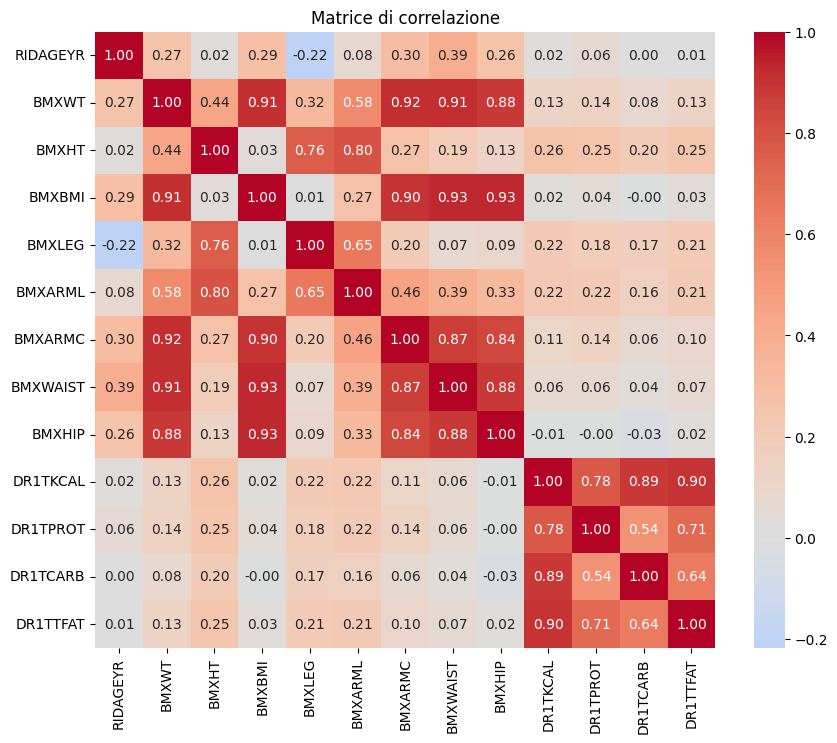

In [647]:
plot_heatmap(df_cleaned)

All'interno della matrice possiamo individuare alcune correlazioni significative tra le variabili:

- **Kcal con proteine, carboidrati e grassi**: le kcal sono una combinazione lineare dei macronutrienti, perciò possiamo rimuovere le kcal e mantenere solo i macronutrienti i quali risultano essere più informativi.
  
- **BMI con altezza e peso**: il BMI è il peso normalizzato per l'altezza, in questo caso possiamo rimuovere altezza e peso e mantenere solo il BMI.

- **Circonferenza del braccio con peso, bmi e vita**: la circonferenza del braccio indica ulteriori informazioni sulla corportatura generale dell'individuo, tutta non aggiunge nell'effettivo alcune informazione clinica quindi può essere tolta.

In [648]:
df_preprocessed = df_cleaned.drop(columns=["DR1TKCAL", "BMXHT", "BMXWT", "BMXARMC"])

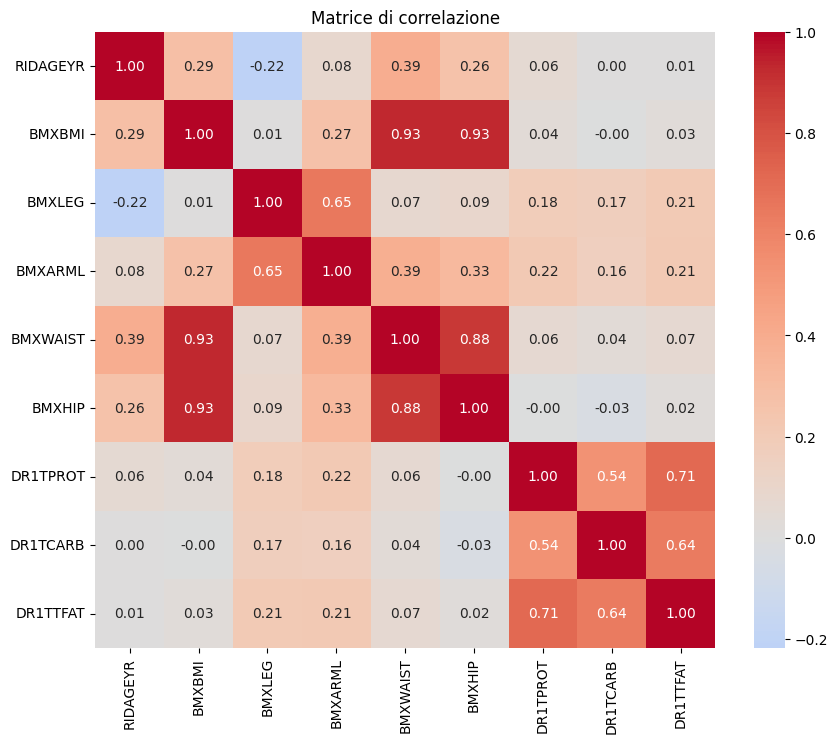

In [649]:
plot_heatmap(df_preprocessed)

## Selezione tramite ElasticNet

La selezione tramite ElasticNet è una selezione effettuata durante l'addestramento andando a portare i coefficienti a 0 per quelle variabili che non hanno impatto sul risultato finale. Essa diventa utile nel momento in cui il filtraggio delle variabili è effettuato su un piccolo set di variabili perché va a comprendere l'effettivo contributo di ogni variabile nell'estrarre il risultato finale.

Noi andremo a utilizzare ElasticNetCV, esso migliora ElasticNet evitando di stimare i parametri:
- `alpha`: quanto penalizzare in totale, ovvero se alpha sarà alto allora i coefficienti tenderanno a essere più piccoli, quindi più variabili azzerate.
- `l1_ratio`: come mixare la regolarizzazione L1 e L2.
Quindi ElasticNetCV al posto di farci indovinare questi parametri li sceglie automaticamente tramite cross-validation, ovvero divide l'addestramento in differenti test e darà in output il test risultato avere l'errore più basso.

La regolarizzazione Lasso ha azzerato il coefficiente della variabile categoriale RIAGENDR_2.0, ovvero la variabile categoriale associata a "Other Hispanic", ciò significa che questo gruppo non viene distinto in modo significativo per predirre il target.

---

# Modello

Ora che abbiamo ottenuto le variabili necessarie possiamo creare il modello di regressione lineare multipla e verificarne le performance:

In [650]:
y = df_preprocessed["DXDTOPF"]
x = df_preprocessed.drop(columns=["DXDTOPF", "SEQN"]) # rimozione di DXDTOPF e SEQN (numero identificativo)
x = pd.get_dummies(x, columns=["RIAGENDR", "RIDRETH3"], drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

pipe = make_pipeline(
    StandardScaler(),
    ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 1.0], max_iter=10000))

enet = pipe.named_steps["elasticnetcv"]

In [651]:
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

In [652]:
# stima di R^2 sui dati di train
scores = cross_val_score(pipe, x_train, y_train, cv=5, scoring='r2')
print(f"R^2 CV: {scores.mean():.3f} ± {scores.std():.3f}")

# Addestramento della pipeline finale su TUTTO il train
pipe.fit(x_train, y_train)

r2_test = pipe.score(x_test, y_test)

# stima di R^2 sui dati di test
print(f"R^2 test: {r2_test:.3f}")

n = x_test.shape[0]
p = (enet.coef_ != 0).sum()        # solo le feature selezionate
print(f"R^2 aggiustato (test): {adjusted_r2(r2_test, n, p):.3f}")

R^2 CV: 0.810 ± 0.023
R^2 test: 0.793
R^2 aggiustato (test): 0.789


In [653]:
print(f"Coeff: {np.array2string(enet.coef_, max_line_width=np.inf)}") # type: ignore
print(f"Intercept: {enet.intercept_}") 
print(f"Alpha: {enet.alpha_}")       
print(f"L1 ratio: {enet.l1_ratio_}")   

Coeff: [-0.56227988 -1.24776447 -0.46142262 -1.09307549  4.93766956  2.55708858 -0.38506297 -0.29881186  0.          4.50821515 -0.08013655 -0.38496229 -0.530016    0.33519971 -0.14210677]
Intercept: 32.563024757804094
Alpha: 0.005800495714361781
L1 ratio: 1.0


In [654]:
selected = x_train.columns[enet.coef_ != 0].tolist()

X_inf = sm.add_constant(x_test[selected].astype(float))
ols = sm.OLS(y_test, X_inf).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                DXDTOPF   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     221.0
Date:                Wed, 17 Jun 2026   Prob (F-statistic):          2.23e-260
Time:                        13:06:01   Log-Likelihood:                -2229.5
No. Observations:                 797   AIC:                             4489.
Df Residuals:                     782   BIC:                             4559.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            9.4654      2.853      3.317   

Da questi risultati possiamo notare che:
- $R^2 = 0.813$, coefficiente di determinazione, esso spiega quanto del fenomeno viene spiegato dal modello di regressione.
- $R^2_{A}=0.811$, coefficiente di determinazione corretto, migliora $R^2$ andando a penalizzare in base al numero di variabili presenti nel modello.
- Il coefficiente della variabile `DR1TTFAT` è portato a 0, ciò significa che la variabile contribuiva poco alla predizione. Notare però che lasceremo comunque la variabile per non storpiare la formula finale e far inserire all'utente comunque tutti e tre i macro.

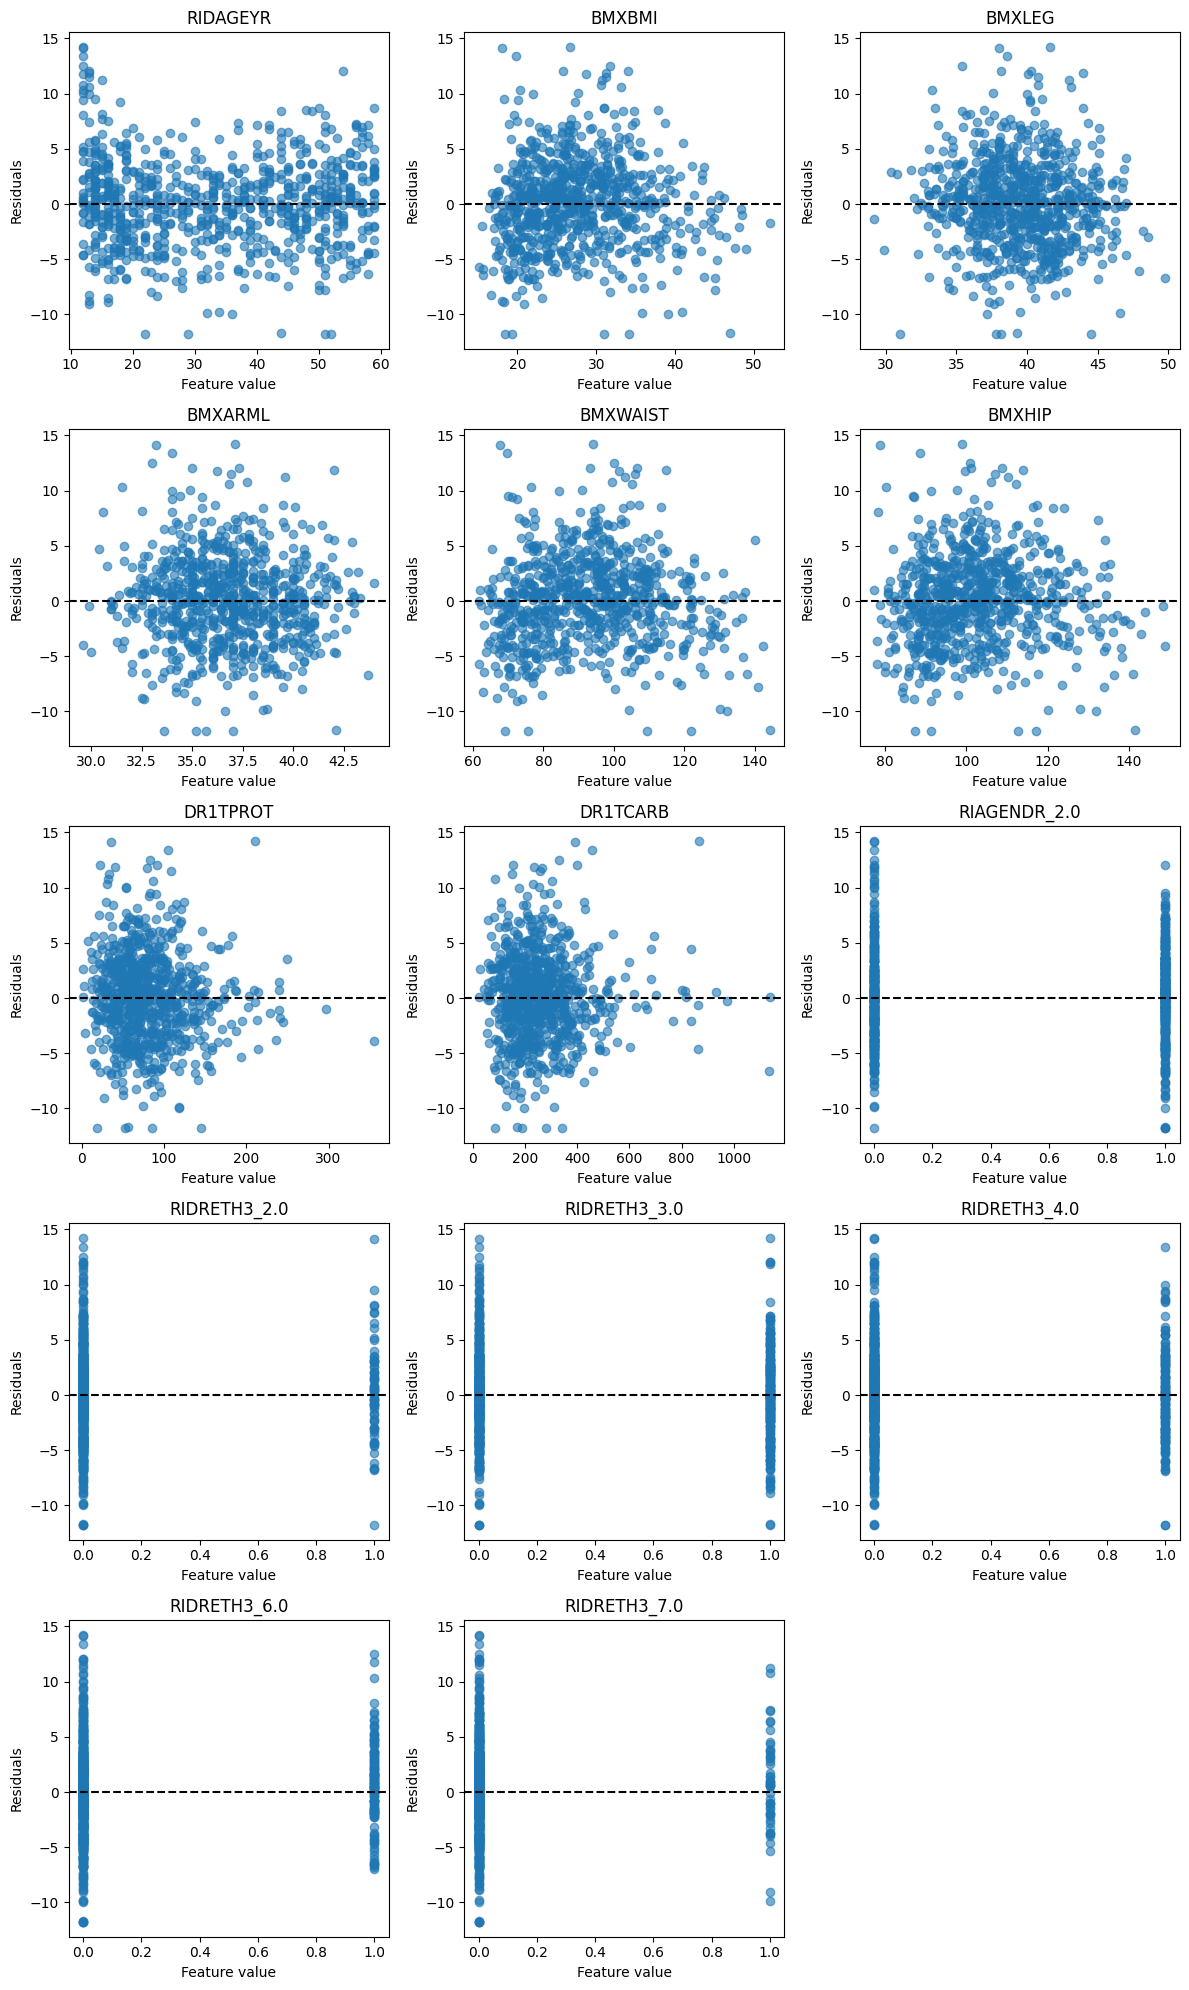

In [655]:
def plot_residuals(residuals, x_const, names):
    n_cols = 3
    n_rows = (len(names) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.flatten()
    for i in range(len(names)):
        name = names[i]
        axes[i].scatter(x_const[name], residuals, alpha=0.6)   # ← per nome colonna
        axes[i].axhline(0, linestyle="--", color="black")
        axes[i].set_title(name)
        axes[i].set_xlabel("Feature value")
        axes[i].set_ylabel("Residuals")

    for j in range(len(names), len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()
    
y_pred = pipe.predict(x_test)
residuals = y_test - y_pred

plot_residuals(residuals, x_test, selected)

I grafici dei residui relativi alle variabili non mostrano alcun pattern evidente, i residui sono distribuiti bene attorno allo zero. Possiamo però verificare se il modello polinomiale apporti comunque un qualche miglioramento: 

In [656]:
cat_cols = [c for c in x.columns if c.startswith(("RIAGENDR_", "RIDRETH3_"))]
num_cols = [c for c in x.columns if c not in cat_cols]

# poly SOLO sulle numeriche, dummy passano intatte
preprocessor = ColumnTransformer(
    transformers=[
        ("poly", PolynomialFeatures(degree=2, include_bias=False), num_cols),
        ("cat", "passthrough", cat_cols),
    ]
)

pipe_poly = make_pipeline(
    preprocessor,
    StandardScaler(),
    ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 1.0], max_iter=10000),
)
enet_poly = pipe.named_steps["elasticnetcv"]

In [657]:
# stima di R^2 sui dati di train
scores = cross_val_score(pipe_poly, x_train, y_train, cv=5, scoring='r2')
print(f"R^2 CV: {scores.mean():.3f} ± {scores.std():.3f}")

# Addestramento della pipeline finale su TUTTO il train
pipe_poly.fit(x_train, y_train)

r2_test = pipe_poly.score(x_test, y_test)

# stima di R^2 sui dati di test
print(f"R^2 test: {r2_test:.3f}")

n = x_test.shape[0]
p = (enet_poly.coef_ != 0).sum()        # solo le feature selezionate
print(f"R^2 aggiustato (test): {adjusted_r2(r2_test, n, p):.3f}")

R^2 CV: 0.844 ± 0.016
R^2 test: 0.830
R^2 aggiustato (test): 0.827


In [658]:
print(f"Coeff: {np.array2string(enet_poly.coef_, max_line_width=np.inf)}") # type: ignore
print(f"Intercept: {enet_poly.intercept_}") 
print(f"Alpha: {enet_poly.alpha_}")       
print(f"L1 ratio: {enet_poly.l1_ratio_}")   

Coeff: [-0.56227988 -1.24776447 -0.46142262 -1.09307549  4.93766956  2.55708858 -0.38506297 -0.29881186  0.          4.50821515 -0.08013655 -0.38496229 -0.530016    0.33519971 -0.14210677]
Intercept: 32.563024757804094
Alpha: 0.005800495714361781
L1 ratio: 1.0


Possiamo notare come nonostante l'aggiunta di variabili data dal modello polinomiale siamo riusciti a ottenere un modello con $R^2_A = 0.827$.  

## Diagnostica del modello

Per verificare che le assunzioni di OLS siano rispettate e che il modello calibri uniformemente effettuiamo le seguenti tre visualizzazioni:

1. **Predetto vs Reale**.
2. **Residui vs Predetto**.
3. **Q-Q plot dei residui**: confronto tra i quantili dei residui e i quantili di una distribuzione normale per verificare che seguano la stessa distribuzione.


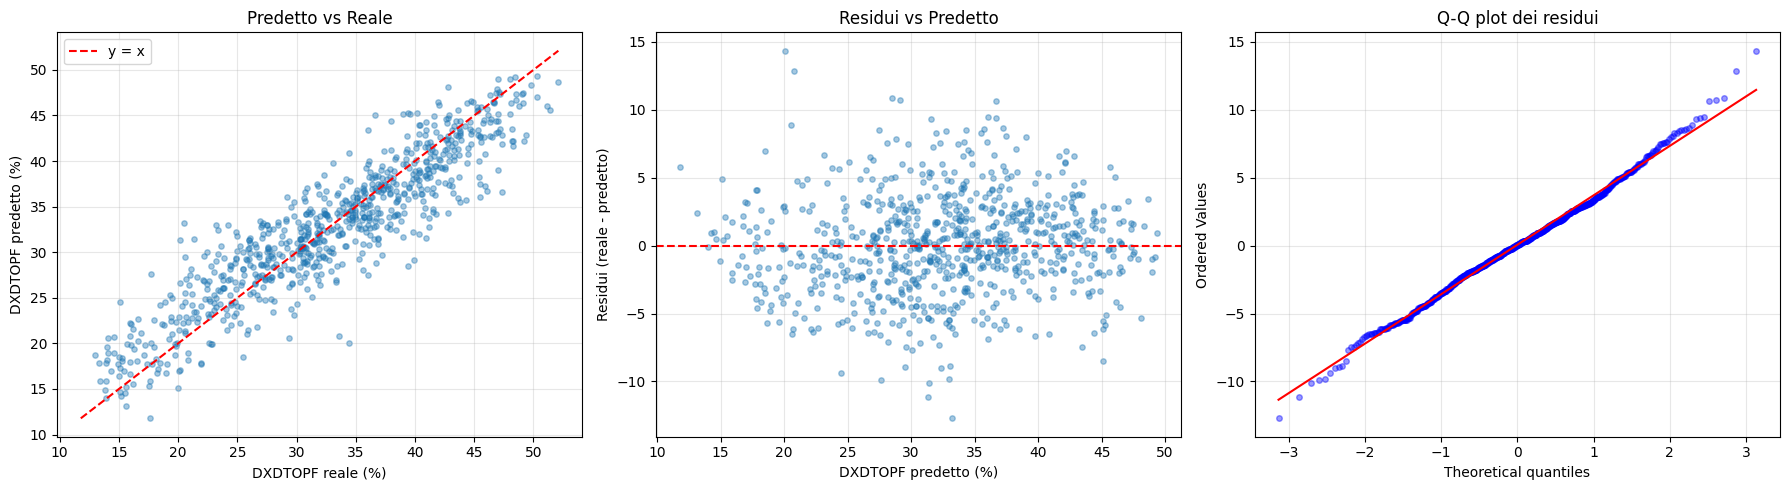

In [ ]:
y_pred = pipe_poly.predict(x_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Predetto vs Reale
axes[0].scatter(y_test, y_pred, alpha=0.4, s=15)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="y = x")
axes[0].set_xlabel("DXDTOPF reale (%)")
axes[0].set_ylabel("DXDTOPF predetto (%)")
axes[0].set_title("Predetto vs Reale")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Residui vs Predetto
axes[1].scatter(y_pred, residuals, alpha=0.4, s=15)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("DXDTOPF predetto (%)")
axes[1].set_ylabel("Residui (reale - predetto)")
axes[1].set_title("Residui vs Predetto")
axes[1].grid(alpha=0.3)

# 3. Q-Q plot dei residui
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot dei residui")
axes[2].get_lines()[0].set_markersize(4)
axes[2].get_lines()[0].set_alpha(0.4)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

- **Predetto vs Reale**: la nuvola di punti risulta ben centrata sulla diagonale con una dispersione abbastanza uniforme, anche se c'è un allontamento più accentuato nei valori di bordo.
- **Residui vs Predetto**: la nuvola di punti mostra una maggioranza di punti compresi nel range [-5, +5], con pochi punti che superano il range. Non si vede nessun pattern effettivo che mostri una forte eteroschedasticità, quindi una varianza non uniforme.
- **Q-Q Plot**: i punti seguono correttamente la retta diagonale in maniera quasi perfetta, tuttavia nelle code estreme si può notare una lieve deviazione. Quindi possiamo assumere che i residui sono approssimativamente normali, con code lievemente più pesanti del normale.

Facciamo inoltre un confronto tra i modelli di regressione appena implementati e le formule viste inizialmente (Deurenberg, CUN-BAE) e confrontiamo il loro $R^2$:

In [ ]:
# Recupera i dati originali del test set
test_idx = y_test.index
df_test = df_cleaned.loc[test_idx]
gender_str = df_test["RIAGENDR"].map({1.0: "M", 2.0: "F"})

# Stime con le formule classiche
bf_deurenberg = deurenberg(df_test["BMXBMI"], df_test["RIDAGEYR"], gender_str)
bf_cunbae = cun_bae(df_test["BMXBMI"], df_test["RIDAGEYR"], gender_str)
bf_ols = pipe.predict(x_test)
bf_ols_poly = pipe_poly.predict(x_test)

# Confronto su test set
y_true = y_test.values
results_poly = {
    "Deurenberg": bf_deurenberg,
    "CUN-BAE": bf_cunbae,
    "OLS lineare": bf_ols,
    "OLS polinom.":bf_ols_poly,
}

print(f"{'Modello':<15} {'R^2':>8} {'RMSE':>8} {'MAE':>8}")
print("-" * 41)
for name, pred in results_poly.items():
    r2 = r2_score(y_true, pred)
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    mae = np.mean(np.abs(y_true - pred))
    print(f"{name:<15} {r2:>8.4f} {rmse:>8.3f} {mae:>8.3f}")

Modello              R^2     RMSE      MAE
-----------------------------------------
Deurenberg        0.3189    7.291    5.731
CUN-BAE           0.4632    6.473    5.028
OLS lineare       0.7926    4.023    3.095
OLS polinom.      0.8303    3.639    2.818


In [661]:
import joblib

bundle = {
    "pipe": pipe_poly,                 
    "feature_names": list(x.columns),  # colonne attese in ingresso (post get_dummies)
    "num_cols": num_cols,
    "cat_cols": cat_cols,
}

joblib.dump(bundle, "fat_percentage_model.joblib")
print("Modello salvato in fat_percentage_model.joblib")

Modello salvato in fat_percentage_model.joblib


# Predizione

Per fare inferenza su nuovi soggetti, ricarichiamo il bundle e applichiamo la pipeline. La funzione `predict_bf` qui sotto incapsula tutti i passaggi e accetta un DataFrame con le stesse colonne del training set (prima di `get_dummies`):


In [662]:
def predict_bf(
    bmi,
    age,
    waist_cm,
    hip_cm,
    thigh_cm,
    arm_length_cm,
    protein_g,
    carb_g,
    fat_g,
    gender,
    ethnicity,
    bundle_path="fat_percentage_model.joblib",
    bundle=None,
):
    """
    Stima la percentuale di massa grassa per un singolo soggetto.

    Args:
        bmi:           BMI in kg/m²
        age:           età in anni
        waist_cm:      circonferenza vita (cm)
        hip_cm:        circonferenza fianchi (cm)
        thigh_cm:      lunghezza della coscia, dal piano del bacino al ginocchio (cm)
        arm_length_cm: lunghezza del braccio superiore (cm)
        protein_g:     proteine giornaliere (g)
        carb_g:        carboidrati giornalieri (g)
        fat_g:         grassi totali giornalieri (g)
        gender:        "M" o "F"
        ethnicity:     codice NHANES RIDRETH3:
                        1 = Mexican-American
                        2 = Other Hispanic
                        3 = Non-Hispanic White
                        4 = Non-Hispanic Black
                        6 = Non-Hispanic Asian
                        7 = Other / Multi-Racial

    Returns:
        float: percentuale di massa grassa stimata
    """

    b = bundle if bundle is not None else joblib.load(bundle_path)
    riagendr = 1.0 if gender.upper() == "M" else 2.0

    row = pd.DataFrame({
        "RIDAGEYR": [age],
        "BMXBMI": [bmi],
        "BMXLEG": [thigh_cm],
        "BMXARML": [arm_length_cm],
        "BMXWAIST": [waist_cm],
        "BMXHIP": [hip_cm],
        "DR1TPROT": [protein_g],
        "DR1TCARB": [carb_g],
        "DR1TTFAT": [fat_g],
    })

    for col in b["cat_cols"]:
        row[col] = 0
    for col in (f"RIAGENDR_{riagendr}", f"RIDRETH3_{float(ethnicity)}"):
        if col in b["cat_cols"]:
            row[col] = 1

    row = row[b["feature_names"]]
    return float(b["pipe"].predict(row)[0])

bf = predict_bf(
    bmi=27.01,
    age=23,
    waist_cm=75,
    hip_cm=80,
    thigh_cm=40,
    arm_length_cm=37,
    protein_g=214.78,
    carb_g=329.92,
    fat_g=98.1,
    gender="M",
    ethnicity=3,
)
print(f"Percentuale di massa grassa stimata: {bf:.1f}%")

Percentuale di massa grassa stimata: 16.1%


---

# Gestione degli errori di misurazione con il metodo Monte Carlo

Il metodo di predizione della massa grassa implementato si basa su misure di circonferenze e lunghezze corporee, che sono però soggette a errori di misurazione. Per attenuare l'impatto di queste imprecisioni è possibile ricorrere alla simulazione di Monte Carlo: facendo variare ciascuna misura all'interno del suo intervallo di errore plausibile e ricalcolando ogni volta la percentuale di massa grassa, si ottiene non un singolo valore puntuale ma un'intera distribuzione di esiti. Da questa distribuzione si possono poi ricavare una stima media più robusta e un intervallo di confidenza che quantifica l'incertezza associata alla misurazione.

In [663]:
def mc_predict_bf(
    bmi,
    age,
    waist_cm,
    hip_cm,
    thigh_cm,
    arm_length_cm,
    protein_g,
    carb_g,
    fat_g,
    gender,
    ethnicity,
    n_sim=10000,
    bundle_path="fat_percentage_model.joblib",
):
    b = joblib.load(bundle_path)
    riagendr = 1.0 if gender.upper() == "M" else 2.0

    rows = pd.DataFrame({
        "RIDAGEYR": np.full(n_sim, age),
        "BMXBMI": np.full(n_sim, bmi),
        "BMXLEG": np.random.normal(thigh_cm, 1.0, n_sim),
        "BMXARML": np.random.normal(arm_length_cm, 1.0, n_sim),
        "BMXWAIST": np.random.normal(waist_cm, 1.0, n_sim),
        "BMXHIP": np.random.normal(hip_cm, 1.0, n_sim),
        "DR1TPROT": np.full(n_sim, protein_g),
        "DR1TCARB": np.full(n_sim, carb_g),
        "DR1TTFAT": np.full(n_sim, fat_g),
    })

    for col in b["cat_cols"]:
        rows[col] = 0
    for col in (f"RIAGENDR_{riagendr}", f"RIDRETH3_{float(ethnicity)}"):
        if col in b["cat_cols"]:
            rows[col] = 1

    rows = rows[b["feature_names"]]

    results = b["pipe"].predict(rows)
    mean = np.mean(results)
    interval = np.percentile(results, [2.5, 97.5])
    return mean, interval

bf, interval = mc_predict_bf(
    bmi=27.01,
    age=23,
    waist_cm=75,
    hip_cm=80,
    thigh_cm=40,
    arm_length_cm=37,
    protein_g=214.78,
    carb_g=329.92,
    fat_g=98.1,
    gender="M",
    ethnicity=3,
)
print(f"Percentuale di massa grassa stimata: {bf:.1f}%, intervallo: {interval[0]:.1f}%-{interval[1]:.1f}%")

Percentuale di massa grassa stimata: 16.1%, intervallo: 14.5%-17.7%
